# Sideview glancing-incidence low-energy method sweep

Four-cell comparison of Fresnel, bidirectional WPM, and bidirectional Pade propagation for Si, Mo, and Au slabs at 10, 20, and 30 keV. The detailed sideview plot uses one selected case; the material/energy sweep records method-difference metrics for all 9 cases.


In [1]:
import importlib
import json
from pathlib import Path
import time

import abtem
from ase.build import bulk
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import wide_angle_propagation.propagation_methods as pm

pm = importlib.reload(pm)
from wide_angle_propagation.propagation_methods import (
    energy2wavelength,
    simulate_bidirectional_pade_bpm_1d,
    simulate_bidirectional_wpm_1d,
    simulate_glancing_fresnel_baseline_1d,
)
from wide_angle_propagation.sideview_geometry import make_tilted_gaussian_beam_1d

abtem.config.set({"device": "cpu"})
abtem.config.set({"precision": "float64"})
jax.config.update("jax_enable_x64", True)


In [ ]:
energy = 30e3

# Physical slab dimensions: keep the 100 nm path length, but use a 50 Angstrom atom slab depth.
slab_width_nm = 100.0
slab_width_A = 10.0 * slab_width_nm
slab_depth_A = 50.0
slab_depth_nm = slab_depth_A / 10.0
u_top_margin_A = 30.0
u_bottom_margin_A = 10.0

# Grid choices avoid tilt aliasing and sample the Si lattice repeat along the path.
n_u = 192
n_steps = 768
pade_order = (4, 4)
backscatter_sweeps = 1
nyquist_safety_fraction = 0.50
u_min_A = -slab_depth_A - u_bottom_margin_A
u_max_A = u_top_margin_A
du = (u_max_A - u_min_A) / n_u
path_step = slab_width_A / n_steps
u = u_min_A + (jnp.arange(n_u) + 0.5) * du
slice_axis = (np.arange(n_steps) + 0.5) * path_step

# Glancing-incidence beam aimed at u=0 halfway through the slab.
glancing_angle_degrees = 1.0
glancing_angle = jnp.deg2rad(glancing_angle_degrees)
input_beam_tilt = -glancing_angle
beam_waist = 3.0
target_atom_u = 0.0
target_path_coordinate = 0.5 * slab_width_A
input_beam_center_u = target_atom_u - target_path_coordinate * jnp.tan(input_beam_tilt)

# Build one cubic Si diamond unit-cell sideview potential with abTEM/Lobato.
si_lattice_A = 5.431
si_unit = bulk("Si", "diamond", a=si_lattice_A, cubic=True)
si_unit.pbc = [True, True, True]
projection_thickness_A = float(si_unit.cell.lengths()[1])
abtem_sampling_A = 0.35

si_potential = abtem.Potential(
    si_unit,
    sampling=abtem_sampling_A,
    slice_thickness=projection_thickness_A,
    projection="finite",
    parametrization="lobato",
    plane="xz",
    device="cpu",
)
si_unit_projected = np.asarray(si_potential.build(lazy=False).array)[0] / projection_thickness_A
unit_du, unit_ds = (float(v) for v in si_potential.sampling)
unit_u_period_A = unit_du * si_unit_projected.shape[0]
unit_s_period_A = unit_ds * si_unit_projected.shape[1]

wavelength_A = float(energy2wavelength(energy))
tilt_frequency = float(jnp.sin(jnp.abs(input_beam_tilt)) / wavelength_A)
nyquist_frequency = 1.0 / (2.0 * du)
tilt_nyquist_fraction = tilt_frequency / nyquist_frequency
lattice_frequency = 1.0 / si_lattice_A
path_nyquist_frequency = 1.0 / (2.0 * path_step)
lattice_nyquist_fraction = lattice_frequency / path_nyquist_frequency
if tilt_nyquist_fraction >= nyquist_safety_fraction:
    raise ValueError("Transverse grid is too close to Nyquist for the tilted input carrier")
if lattice_nyquist_fraction >= nyquist_safety_fraction:
    raise ValueError("Path grid is too close to Nyquist for the Si lattice repeat")

# Tile the abTEM unit-cell potential onto the slab dimensions at the method grid points.
u_np = np.asarray(u)
s_np = np.asarray(slice_axis)
slab_mask = (u_np >= -slab_depth_A) & (u_np <= 0.0)
slab_depth_coordinate = u_np[slab_mask] + slab_depth_A
u_indices = np.floor(np.mod(slab_depth_coordinate, unit_u_period_A) / unit_du).astype(int)
s_indices = np.floor(np.mod(s_np, unit_s_period_A) / unit_ds).astype(int)
u_indices = np.clip(u_indices, 0, si_unit_projected.shape[0] - 1)
s_indices = np.clip(s_indices, 0, si_unit_projected.shape[1] - 1)

potential_slices_np = np.zeros((n_steps, n_u), dtype=np.float64)
potential_slices_np[:, slab_mask] = si_unit_projected[np.ix_(u_indices, s_indices)].T
potential_slices = jnp.asarray(potential_slices_np)

# Atom markers for plotting only. The simulated potential above comes from the tiled Lobato unit cell.
unit_positions = np.asarray(si_unit.positions, dtype=float)
unit_u_positions = unit_positions[:, 0]
unit_s_positions = unit_positions[:, 2]
n_tile_u = int(np.ceil(slab_depth_A / si_lattice_A)) + 1
n_tile_s = int(np.ceil(slab_width_A / si_lattice_A)) + 1
atom_marker_u = []
atom_marker_s = []
for iu in range(n_tile_u):
    for is_ in range(n_tile_s):
        atom_marker_u.append(-slab_depth_A + unit_u_positions + iu * si_lattice_A)
        atom_marker_s.append(unit_s_positions + is_ * si_lattice_A)
atom_marker_u = np.concatenate(atom_marker_u)
atom_marker_s = np.concatenate(atom_marker_s)
marker_mask = (
    (atom_marker_u >= -slab_depth_A)
    & (atom_marker_u <= 0.0)
    & (atom_marker_s >= 0.0)
    & (atom_marker_s <= slab_width_A)
)
atom_marker_u = atom_marker_u[marker_mask]
atom_marker_s = atom_marker_s[marker_mask]

input_wave = make_tilted_gaussian_beam_1d(
    u,
    energy,
    waist=beam_waist,
    center=input_beam_center_u,
    tilt=input_beam_tilt,
).astype(jnp.complex128)


def precompute_detail_pade_operators(potential_slices_case, slice_keys, dx, dz, energy_eV, order):
    operators = {}
    keys = np.asarray(slice_keys)
    k0 = 1.0 / energy2wavelength(energy_eV)
    for key in np.unique(keys):
        first_index = int(np.flatnonzero(keys == key)[0])
        operator_x, n0 = pm.build_sideview_operator_x_1d(
            potential_slices_case[first_index],
            dx,
            energy_eV,
            n0_mode="slice_mean",
            transverse_operator="spectral",
        )
        sqrt_operator = pm._pade_sqrt_matrix(operator_x, order)
        generator = 1j * 2.0 * jnp.pi * dz * k0 * n0 * sqrt_operator
        operators[int(key)] = {
            "forward": jax.scipy.linalg.expm(generator),
            "backward": jax.scipy.linalg.expm(-generator),
        }
    return operators


def apply_detail_interface(scattering_matrix, plus_from_left, minus_from_right):
    plus_right = scattering_matrix[0, 0] * plus_from_left + scattering_matrix[0, 1] * minus_from_right
    minus_left = scattering_matrix[1, 0] * plus_from_left + scattering_matrix[1, 1] * minus_from_right
    return plus_right, minus_left


def simulate_cached_pade_detail(potential_slices_case, slice_keys, input_wave_case, dx, dz, energy_eV, *, order, n_sweeps):
    n_slices = potential_slices_case.shape[0]
    keys = np.asarray(slice_keys)
    zero = jnp.zeros_like(input_wave_case)
    operators = precompute_detail_pade_operators(potential_slices_case, keys, dx, dz, energy_eV, order)
    refractive_maps = pm.klein_gordon_refractive_index_1d(potential_slices_case, energy_eV)
    interface_matrices = [
        pm.interface_scattering_matrix_1d(refractive_maps[j], refractive_maps[j + 1])
        for j in range(n_slices - 1)
    ]

    def forward_pass(backward_boundary):
        wave_plus = input_wave_case
        wavefronts_plus = []
        plus_at_interfaces = [zero for _ in range(n_slices + 1)]
        for j in range(n_slices):
            wave_plus = operators[int(keys[j])]["forward"] @ wave_plus
            wavefronts_plus.append(wave_plus)
            plus_at_interfaces[j + 1] = wave_plus
            if j + 1 < n_slices:
                wave_plus, _ = apply_detail_interface(interface_matrices[j], wave_plus, backward_boundary[j + 1])
        return wave_plus, wavefronts_plus, plus_at_interfaces

    def backward_pass(plus_at_interfaces):
        new_backward = [zero for _ in range(n_slices + 1)]
        wave_minus = zero
        for j in range(n_slices - 2, -1, -1):
            new_backward[j + 1] = wave_minus
            _, minus_left = apply_detail_interface(interface_matrices[j], plus_at_interfaces[j + 1], wave_minus)
            wave_minus = operators[int(keys[j])]["backward"] @ minus_left
            new_backward[j] = wave_minus
        return new_backward

    backward_boundary = [zero for _ in range(n_slices + 1)]
    residuals = []
    for _ in range(max(int(n_sweeps), 1)):
        _, _, plus_at_interfaces = forward_pass(backward_boundary)
        new_backward = backward_pass(plus_at_interfaces)
        residuals.append(float(pm._residual_between_boundary_lists(new_backward, backward_boundary, input_wave_case)))
        backward_boundary = new_backward

    transmitted, wavefronts_plus, plus_at_interfaces = forward_pass(backward_boundary)
    final_backward = backward_pass(plus_at_interfaces)
    return transmitted, final_backward[0], {
        "wavefronts_plus": jnp.stack(wavefronts_plus),
        "residual_per_sweep": residuals,
        "cached_unique_slices": int(np.unique(keys).size),
    }

method_results = {}
fresnel_wave, _, fresnel_diag = simulate_glancing_fresnel_baseline_1d(
    input_wave,
    potential_slices,
    du,
    path_step,
    energy,
    input_tilt=0.0,
)
method_results["Fresnel"] = {
    "wave": fresnel_wave,
    "reflected": jnp.zeros_like(fresnel_wave),
    "wavefronts": fresnel_diag["wavefronts"],
    "diagnostics": fresnel_diag,
}

wpm_wave, wpm_reflected, _, wpm_diag = simulate_bidirectional_wpm_1d(
    potential_slices,
    input_wave,
    du,
    path_step,
    energy,
    n_bins=32,
    n_sweeps=backscatter_sweeps,
)
method_results["WPM"] = {
    "wave": wpm_wave,
    "reflected": wpm_reflected,
    "wavefronts": wpm_diag["wavefronts_plus"],
    "diagnostics": wpm_diag,
}

pade_wave, pade_reflected, pade_diag = simulate_cached_pade_detail(
    potential_slices,
    s_indices,
    input_wave,
    du,
    path_step,
    energy,
    order=pade_order,
    n_sweeps=backscatter_sweeps,
)
method_results["Pade"] = {
    "wave": pade_wave,
    "reflected": pade_reflected,
    "wavefronts": pade_diag["wavefronts_plus"],
    "diagnostics": pade_diag,
}

spatial_frequency = np.fft.fftshift(np.fft.fftfreq(n_u, d=du))
detector_angle_rad = np.arcsin(np.clip(spatial_frequency * wavelength_A, -1.0, 1.0))
detector_angle_mrad = 1e3 * detector_angle_rad
incident_angle_mrad = 1e3 * float(input_beam_tilt)
bounced_angle_mrad = -incident_angle_mrad
positive_angle_mask = detector_angle_mrad > 0.0
method_farfields = {
    name: jnp.abs(jnp.fft.fftshift(jnp.fft.fft(result["wave"]))) ** 2
    for name, result in method_results.items()
}


def align_to_reference(candidate, reference):
    scale = jnp.vdot(candidate, reference) / (jnp.vdot(candidate, candidate) + 1e-30)
    return scale * candidate


def relative_complex_rmse(candidate, reference, mask=None):
    candidate = align_to_reference(candidate, reference)
    if mask is not None:
        candidate = candidate[mask]
        reference = reference[mask]
    return jnp.linalg.norm(candidate - reference) / (jnp.linalg.norm(reference) + 1e-30)


def normalized_profile_rmse(candidate_values, reference_values, mask=None):
    candidate_values = jnp.asarray(candidate_values)
    reference_values = jnp.asarray(reference_values)
    if mask is not None:
        candidate_values = candidate_values[mask]
        reference_values = reference_values[mask]
    scale = jnp.vdot(candidate_values, reference_values) / (
        jnp.vdot(candidate_values, candidate_values) + 1e-30
    )
    return jnp.sqrt(jnp.mean((scale * candidate_values - reference_values) ** 2)) / (
        jnp.sqrt(jnp.mean(reference_values**2)) + 1e-30
    )

exit_mask = jnp.abs(fresnel_wave) ** 2 > 1e-3 * jnp.max(jnp.abs(fresnel_wave) ** 2)
comparison_summary = {}
for name, result in method_results.items():
    comparison_summary[name] = {
        "exit_field_rmse_vs_fresnel": float(relative_complex_rmse(result["wave"], fresnel_wave, exit_mask)),
        "exit_intensity_rmse_vs_fresnel": float(
            normalized_profile_rmse(jnp.abs(result["wave"]) ** 2, jnp.abs(fresnel_wave) ** 2, exit_mask)
        ),
        "wide_angle_farfield_rmse_vs_fresnel": float(
            normalized_profile_rmse(method_farfields[name][positive_angle_mask], method_farfields["Fresnel"][positive_angle_mask])
        ),
        "reflected_power": float(jnp.sum(jnp.abs(result["reflected"]) ** 2)),
        "transmitted_power": float(jnp.sum(jnp.abs(result["wave"]) ** 2)),
    }

assert all(jnp.all(jnp.isfinite(result["wave"])) for result in method_results.values())
assert all(np.isfinite(value) for row in comparison_summary.values() for value in row.values())

# Material/energy survey. This keeps the same 100 nm x 50 A physical slab, but uses
# a dedicated survey grid so that 9 material/energy cases are feasible.
run_material_energy_survey = True
survey_material_specs = {
    "Si": {"symbol": "Si", "crystalstructure": "diamond", "a": 5.431},
    "Mo": {"symbol": "Mo", "crystalstructure": "bcc", "a": 3.147},
    "Au": {"symbol": "Au", "crystalstructure": "fcc", "a": 4.078},
}
survey_energies_eV = [10e3, 20e3, 30e3]
survey_n_u = 192
survey_path_step_target_A = 0.75
survey_n_steps = int(np.ceil(slab_width_A / survey_path_step_target_A))
survey_pade_order = pade_order
survey_backscatter_sweeps = 1
survey_wpm_bins = 32
use_saved_survey_results = True
survey_cache_dir = Path("notebook_results") / "sideview_glancing_incidence_low_energy_methods"
survey_cache_tag = (
    f"width{slab_width_A:.0f}A_depth{slab_depth_A:.0f}A_angle{glancing_angle_degrees:.1f}_"
    f"grid{survey_n_steps}x{survey_n_u}_pade{survey_pade_order[0]}{survey_pade_order[1]}_"
    f"sweeps{survey_backscatter_sweeps}_v2"
).replace(".", "p")
survey_case_cache_dir = survey_cache_dir / survey_cache_tag
survey_case_cache_dir.mkdir(parents=True, exist_ok=True)
survey_summary_path = survey_case_cache_dir / "survey_summary.json"
unit_potential_cache = {}


def build_unit_projected_potential(material_spec):
    cache_key = (material_spec["symbol"], material_spec["crystalstructure"], float(material_spec["a"]))
    if cache_key in unit_potential_cache:
        return unit_potential_cache[cache_key]

    atoms = bulk(
        material_spec["symbol"],
        material_spec["crystalstructure"],
        a=material_spec["a"],
        cubic=True,
    )
    atoms.pbc = [True, True, True]
    projection_thickness = float(atoms.cell.lengths()[1])
    potential = abtem.Potential(
        atoms,
        sampling=abtem_sampling_A,
        slice_thickness=projection_thickness,
        projection="finite",
        parametrization="lobato",
        plane="xz",
        device="cpu",
    )
    projected = np.asarray(potential.build(lazy=False).array)[0] / projection_thickness
    unit_sampling = tuple(float(v) for v in potential.sampling)
    result = {
        "atoms": atoms,
        "projected": projected,
        "unit_du": unit_sampling[0],
        "unit_ds": unit_sampling[1],
        "unit_u_period_A": unit_sampling[0] * projected.shape[0],
        "unit_s_period_A": unit_sampling[1] * projected.shape[1],
    }
    unit_potential_cache[cache_key] = result
    return result


def build_survey_case(material_label, energy_eV):
    spec = survey_material_specs[material_label]
    unit = build_unit_projected_potential(spec)
    case_du = (u_max_A - u_min_A) / survey_n_u
    case_path_step = slab_width_A / survey_n_steps
    case_u = u_min_A + (jnp.arange(survey_n_u) + 0.5) * case_du
    case_slice_axis = (np.arange(survey_n_steps) + 0.5) * case_path_step

    case_wavelength_A = float(energy2wavelength(energy_eV))
    case_tilt_frequency = float(jnp.sin(jnp.abs(input_beam_tilt)) / case_wavelength_A)
    case_tilt_nyquist_fraction = case_tilt_frequency / (1.0 / (2.0 * case_du))
    case_lattice_nyquist_fraction = (1.0 / spec["a"]) / (1.0 / (2.0 * case_path_step))
    if case_tilt_nyquist_fraction >= nyquist_safety_fraction:
        raise ValueError(f"{material_label} {energy_eV/1e3:.0f} keV transverse grid is too close to Nyquist")
    if case_lattice_nyquist_fraction >= nyquist_safety_fraction:
        raise ValueError(f"{material_label} {energy_eV/1e3:.0f} keV path grid is too close to Nyquist")

    u_np = np.asarray(case_u)
    s_np = np.asarray(case_slice_axis)
    slab_mask = (u_np >= -slab_depth_A) & (u_np <= 0.0)
    slab_depth_coordinate = u_np[slab_mask] + slab_depth_A
    u_indices = np.floor(np.mod(slab_depth_coordinate, unit["unit_u_period_A"]) / unit["unit_du"]).astype(int)
    s_indices = np.floor(np.mod(s_np, unit["unit_s_period_A"]) / unit["unit_ds"]).astype(int)
    u_indices = np.clip(u_indices, 0, unit["projected"].shape[0] - 1)
    s_indices = np.clip(s_indices, 0, unit["projected"].shape[1] - 1)

    potential_np = np.zeros((survey_n_steps, survey_n_u), dtype=np.float64)
    potential_np[:, slab_mask] = unit["projected"][np.ix_(u_indices, s_indices)].T
    input_center = target_atom_u - target_path_coordinate * jnp.tan(input_beam_tilt)
    case_input_wave = make_tilted_gaussian_beam_1d(
        case_u,
        energy_eV,
        waist=beam_waist,
        center=input_center,
        tilt=input_beam_tilt,
    ).astype(jnp.complex128)

    return {
        "material": material_label,
        "energy_eV": energy_eV,
        "potential_slices": jnp.asarray(potential_np),
        "slice_keys": s_indices.astype(int),
        "input_wave": case_input_wave,
        "u": case_u,
        "du": case_du,
        "path_step": case_path_step,
        "wavelength_A": case_wavelength_A,
        "tilt_nyquist_fraction": case_tilt_nyquist_fraction,
        "lattice_nyquist_fraction": case_lattice_nyquist_fraction,
    }


def precompute_pade_operators_for_keys(potential_slices_case, slice_keys, dx, dz, energy_eV, order):
    operators = {}
    keys = np.asarray(slice_keys)
    k0 = 1.0 / energy2wavelength(energy_eV)
    for key in np.unique(keys):
        first_index = int(np.flatnonzero(keys == key)[0])
        operator_x, n0 = pm.build_sideview_operator_x_1d(
            potential_slices_case[first_index],
            dx,
            energy_eV,
            n0_mode="slice_mean",
            transverse_operator="spectral",
        )
        sqrt_operator = pm._pade_sqrt_matrix(operator_x, order)
        generator = 1j * 2.0 * jnp.pi * dz * k0 * n0 * sqrt_operator
        operators[int(key)] = {
            "forward": jax.scipy.linalg.expm(generator),
            "backward": jax.scipy.linalg.expm(-generator),
        }
    return operators


def apply_scalar_interface_matrix(scattering_matrix, plus_from_left, minus_from_right):
    plus_right = scattering_matrix[0, 0] * plus_from_left + scattering_matrix[0, 1] * minus_from_right
    minus_left = scattering_matrix[1, 0] * plus_from_left + scattering_matrix[1, 1] * minus_from_right
    return plus_right, minus_left


def simulate_cached_pade_exit(case, *, order, n_sweeps):
    potential_case = case["potential_slices"]
    slice_keys = np.asarray(case["slice_keys"])
    input_wave_case = case["input_wave"]
    n_slices = potential_case.shape[0]
    zero = jnp.zeros_like(input_wave_case)
    operators = precompute_pade_operators_for_keys(
        potential_case,
        slice_keys,
        case["du"],
        case["path_step"],
        case["energy_eV"],
        order,
    )
    refractive_maps = pm.klein_gordon_refractive_index_1d(potential_case, case["energy_eV"])
    interface_matrices = [
        pm.interface_scattering_matrix_1d(refractive_maps[j], refractive_maps[j + 1])
        for j in range(n_slices - 1)
    ]

    def forward_pass(backward_boundary):
        wave_plus = input_wave_case
        plus_at_interfaces = [zero for _ in range(n_slices + 1)]
        for j in range(n_slices):
            wave_plus = operators[int(slice_keys[j])]["forward"] @ wave_plus
            plus_at_interfaces[j + 1] = wave_plus
            if j + 1 < n_slices:
                wave_plus, _ = apply_scalar_interface_matrix(
                    interface_matrices[j],
                    wave_plus,
                    backward_boundary[j + 1],
                )
        return wave_plus, plus_at_interfaces

    def backward_pass(plus_at_interfaces):
        new_backward = [zero for _ in range(n_slices + 1)]
        wave_minus = zero
        for j in range(n_slices - 2, -1, -1):
            new_backward[j + 1] = wave_minus
            _, minus_left = apply_scalar_interface_matrix(
                interface_matrices[j],
                plus_at_interfaces[j + 1],
                wave_minus,
            )
            wave_minus = operators[int(slice_keys[j])]["backward"] @ minus_left
            new_backward[j] = wave_minus
        return new_backward

    backward_boundary = [zero for _ in range(n_slices + 1)]
    residuals = []
    for _ in range(max(int(n_sweeps), 1)):
        _, plus_at_interfaces = forward_pass(backward_boundary)
        new_backward = backward_pass(plus_at_interfaces)
        residuals.append(float(pm._residual_between_boundary_lists(new_backward, backward_boundary, input_wave_case)))
        backward_boundary = new_backward

    transmitted, plus_at_interfaces = forward_pass(backward_boundary)
    final_backward = backward_pass(plus_at_interfaces)
    reflected = final_backward[0]
    return transmitted, reflected, {"residual_per_sweep": residuals, "cached_unique_slices": int(np.unique(slice_keys).size)}


def survey_case_cache_path(material_label, energy_eV):
    energy_label = int(round(energy_eV / 1e3))
    return survey_case_cache_dir / f"{material_label}_{energy_label:02d}keV_cross_sections.npz"


def load_cached_survey_row(cache_path):
    with np.load(cache_path, allow_pickle=False) as data:
        row = json.loads(data["metadata_json"].item())
    row["cache_file"] = str(cache_path)
    row["loaded_from_cache"] = True
    return row


def load_survey_case_cross_sections(cache_file):
    with np.load(cache_file, allow_pickle=False) as data:
        result = {name: data[name].copy() for name in data.files if name != "metadata_json"}
        result["metadata"] = json.loads(data["metadata_json"].item())
    return result


def save_survey_case_cross_sections(
    cache_path,
    case,
    row,
    angles_mrad,
    fresnel_exit,
    wpm_exit,
    pade_exit,
    wpm_reflected,
    pade_reflected,
    farfields,
):
    metadata = dict(row)
    metadata["loaded_from_cache"] = False
    np.savez_compressed(
        cache_path,
        metadata_json=np.array(json.dumps(metadata)),
        u_A=np.asarray(case["u"]),
        detector_angle_mrad=np.asarray(angles_mrad),
        fresnel_exit=np.asarray(fresnel_exit),
        wpm_exit=np.asarray(wpm_exit),
        pade_exit=np.asarray(pade_exit),
        wpm_reflected=np.asarray(wpm_reflected),
        pade_reflected=np.asarray(pade_reflected),
        fresnel_farfield=np.asarray(farfields["Fresnel"]),
        wpm_farfield=np.asarray(farfields["WPM"]),
        pade_farfield=np.asarray(farfields["Pade"]),
    )


def run_material_energy_case(material_label, energy_eV):
    cache_path = survey_case_cache_path(material_label, energy_eV)
    if use_saved_survey_results and cache_path.exists():
        return load_cached_survey_row(cache_path)

    case = build_survey_case(material_label, energy_eV)
    start = time.perf_counter()
    fresnel_exit, _, _ = simulate_glancing_fresnel_baseline_1d(
        case["input_wave"],
        case["potential_slices"],
        case["du"],
        case["path_step"],
        energy_eV,
        input_tilt=0.0,
    )
    wpm_exit, wpm_reflected, _, wpm_diag = simulate_bidirectional_wpm_1d(
        case["potential_slices"],
        case["input_wave"],
        case["du"],
        case["path_step"],
        energy_eV,
        n_bins=survey_wpm_bins,
        n_sweeps=survey_backscatter_sweeps,
    )
    pade_exit, pade_reflected, pade_diag = simulate_cached_pade_exit(
        case,
        order=survey_pade_order,
        n_sweeps=survey_backscatter_sweeps,
    )
    elapsed_s = time.perf_counter() - start

    farfields = {
        "Fresnel": jnp.abs(jnp.fft.fftshift(jnp.fft.fft(fresnel_exit))) ** 2,
        "WPM": jnp.abs(jnp.fft.fftshift(jnp.fft.fft(wpm_exit))) ** 2,
        "Pade": jnp.abs(jnp.fft.fftshift(jnp.fft.fft(pade_exit))) ** 2,
    }
    frequencies = np.fft.fftshift(np.fft.fftfreq(survey_n_u, d=case["du"]))
    angles_mrad = 1e3 * np.arcsin(np.clip(frequencies * case["wavelength_A"], -1.0, 1.0))
    positive_mask = angles_mrad > 0.0
    exit_mask_case = jnp.abs(fresnel_exit) ** 2 > 1e-3 * jnp.max(jnp.abs(fresnel_exit) ** 2)

    row = {
        "material": material_label,
        "energy_keV": float(energy_eV / 1e3),
        "grid_shape": tuple(case["potential_slices"].shape),
        "sampling_A": (float(case["du"]), float(case["path_step"])),
        "tilt_nyquist_fraction": float(case["tilt_nyquist_fraction"]),
        "lattice_nyquist_fraction": float(case["lattice_nyquist_fraction"]),
        "cached_unique_slices": pade_diag["cached_unique_slices"],
        "cache_file": str(cache_path),
        "loaded_from_cache": False,
        "runtime_s": float(elapsed_s),
        "wpm_exit_intensity_rmse_vs_fresnel": float(normalized_profile_rmse(jnp.abs(wpm_exit) ** 2, jnp.abs(fresnel_exit) ** 2, exit_mask_case)),
        "pade_exit_intensity_rmse_vs_fresnel": float(normalized_profile_rmse(jnp.abs(pade_exit) ** 2, jnp.abs(fresnel_exit) ** 2, exit_mask_case)),
        "pade_exit_intensity_rmse_vs_wpm": float(normalized_profile_rmse(jnp.abs(pade_exit) ** 2, jnp.abs(wpm_exit) ** 2, exit_mask_case)),
        "wpm_farfield_rmse_vs_fresnel": float(normalized_profile_rmse(farfields["WPM"][positive_mask], farfields["Fresnel"][positive_mask])),
        "pade_farfield_rmse_vs_fresnel": float(normalized_profile_rmse(farfields["Pade"][positive_mask], farfields["Fresnel"][positive_mask])),
        "pade_farfield_rmse_vs_wpm": float(normalized_profile_rmse(farfields["Pade"][positive_mask], farfields["WPM"][positive_mask])),
        "wpm_reflected_power": float(jnp.sum(jnp.abs(wpm_reflected) ** 2)),
        "pade_reflected_power": float(jnp.sum(jnp.abs(pade_reflected) ** 2)),
        "wpm_residual_last": float(wpm_diag["residual_per_sweep"][-1]) if len(wpm_diag["residual_per_sweep"]) else 0.0,
        "pade_residual_last": float(pade_diag["residual_per_sweep"][-1]) if len(pade_diag["residual_per_sweep"]) else 0.0,
    }
    assert all(np.isfinite(value) for key, value in row.items() if isinstance(value, float))
    save_survey_case_cross_sections(
        cache_path,
        case,
        row,
        angles_mrad,
        fresnel_exit,
        wpm_exit,
        pade_exit,
        wpm_reflected,
        pade_reflected,
        farfields,
    )
    return row


survey_results = []
if run_material_energy_survey:
    for material_label in survey_material_specs:
        for survey_energy in survey_energies_eV:
            survey_results.append(run_material_energy_case(material_label, survey_energy))
survey_nyquist_fraction_max = (
    max(max(row["tilt_nyquist_fraction"], row["lattice_nyquist_fraction"]) for row in survey_results)
    if survey_results
    else 0.0
)
survey_summary = {
    "cache_dir": str(survey_case_cache_dir),
    "summary_file": str(survey_summary_path),
    "survey_cases": len(survey_results),
    "survey_grid_shape": (survey_n_steps, survey_n_u),
    "survey_pade_order": survey_pade_order,
    "survey_worst_nyquist_fraction": survey_nyquist_fraction_max,
    "nyquist_safety_fraction": nyquist_safety_fraction,
    "survey_results": survey_results,
}
if run_material_energy_survey:
    survey_summary_path.write_text(json.dumps(survey_summary, indent=2))

{
    "single_case": {
        "slab_size_nm": (slab_width_nm, slab_depth_nm),
        "method_grid_shape": potential_slices.shape,
        "grid_sampling_A": (du, path_step),
        "pade_order": pade_order,
        "backscatter_sweeps": backscatter_sweeps,
        "cached_unique_slices": pade_diag["cached_unique_slices"],
        "nyquist_safety_fraction": nyquist_safety_fraction,
        "tilt_nyquist_fraction": tilt_nyquist_fraction,
        "lattice_nyquist_fraction": lattice_nyquist_fraction,
        "summary": comparison_summary,
    },
    "survey_cases": len(survey_results),
    "survey_cache_dir": str(survey_case_cache_dir),
    "survey_summary_file": str(survey_summary_path),
    "survey_grid_shape": (survey_n_steps, survey_n_u),
    "survey_pade_order": survey_pade_order,
    "survey_worst_nyquist_fraction": survey_nyquist_fraction_max,
    "survey_results": survey_results,
}


{'single_case': {'slab_size_nm': (100.0, 5.0),
  'method_grid_shape': (768, 192),
  'grid_sampling_A': (0.46875, 1.3020833333333333),
  'pade_order': (4, 4),
  'backscatter_sweeps': 1,
  'cached_unique_slices': 16,
  'nyquist_safety_fraction': 0.5,
  'tilt_nyquist_fraction': 0.4688049272391163,
  'lattice_nyquist_fraction': 0.4795003989443319,
  'summary': {'Fresnel': {'exit_field_rmse_vs_fresnel': 0.0,
    'exit_intensity_rmse_vs_fresnel': 0.0,
    'wide_angle_farfield_rmse_vs_fresnel': 0.0,
    'reflected_power': 0.0,
    'transmitted_power': 11.34370462787793},
   'WPM': {'exit_field_rmse_vs_fresnel': 0.013166996597880246,
    'exit_intensity_rmse_vs_fresnel': 0.008518384883827178,
    'wide_angle_farfield_rmse_vs_fresnel': 0.023749725501489356,
    'reflected_power': 7.208262188616299e-09,
    'transmitted_power': 11.33765293812433},
   'Pade': {'exit_field_rmse_vs_fresnel': 0.0071327746140875305,
    'exit_intensity_rmse_vs_fresnel': 0.005676268807017466,
    'wide_angle_farfield_

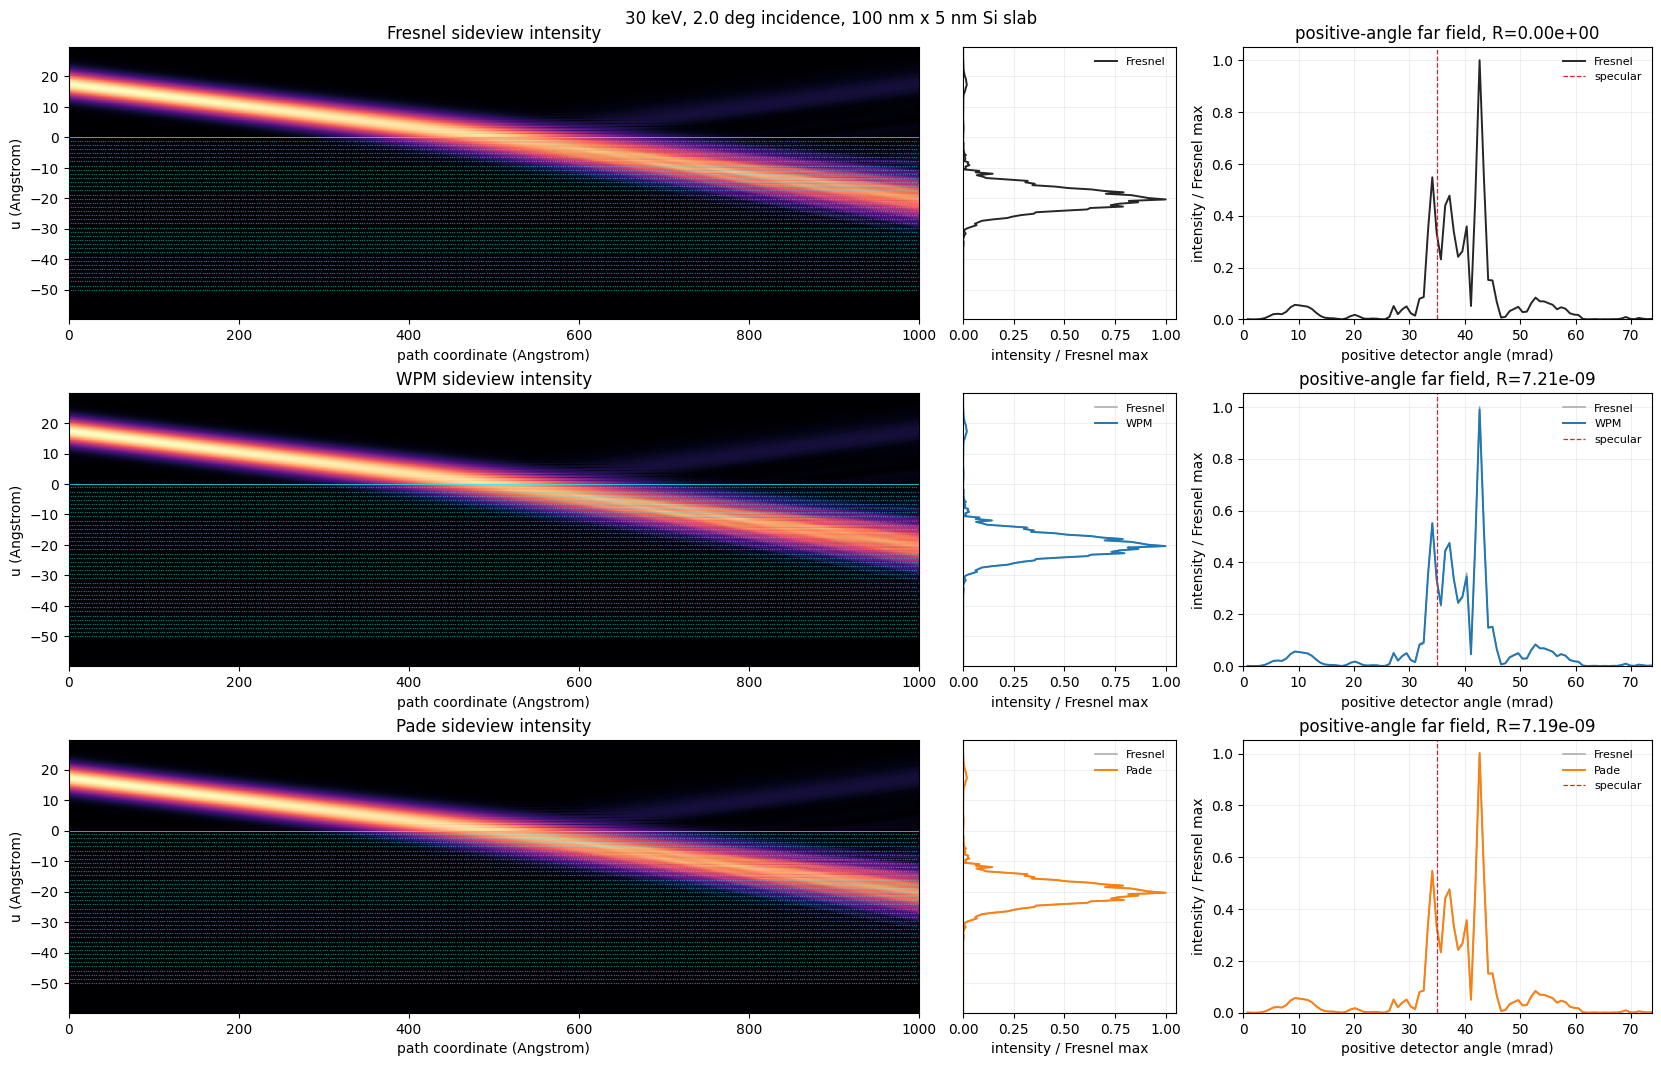

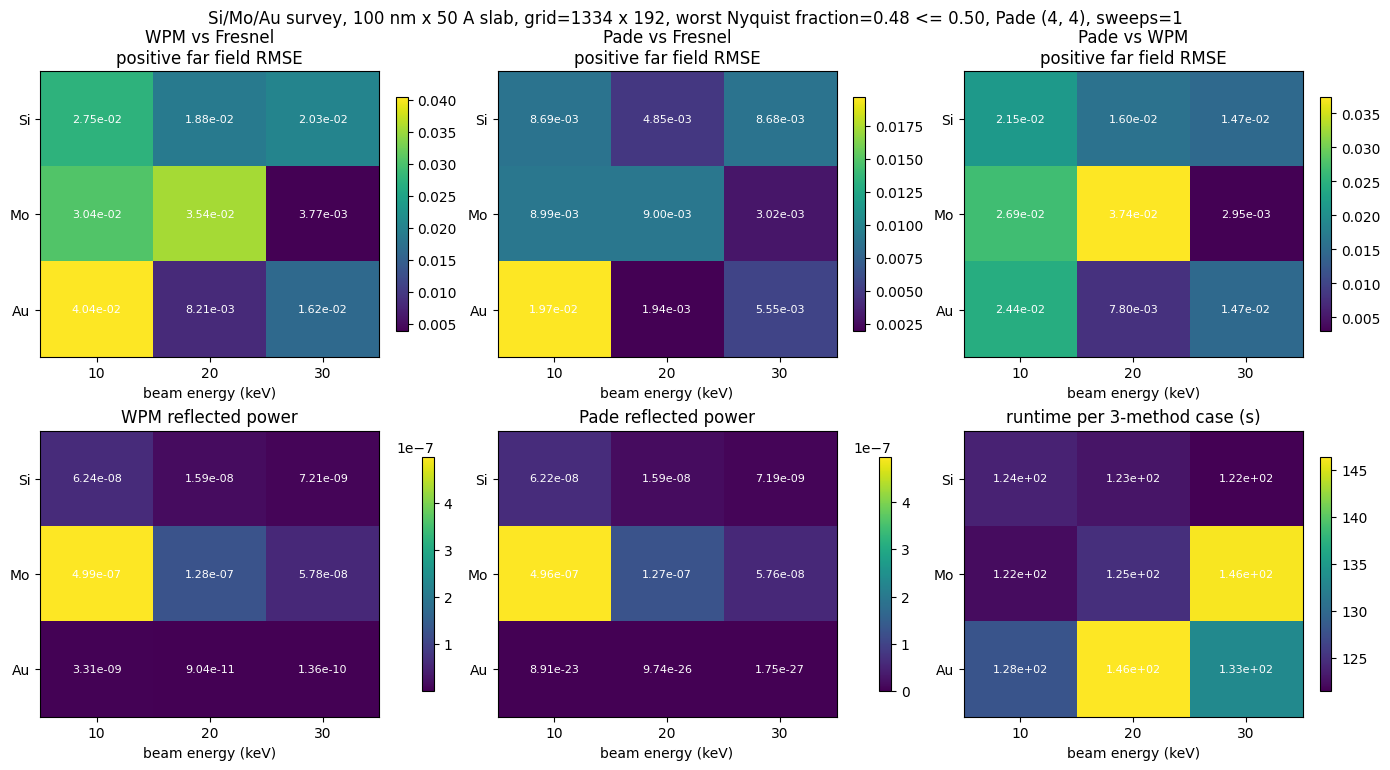

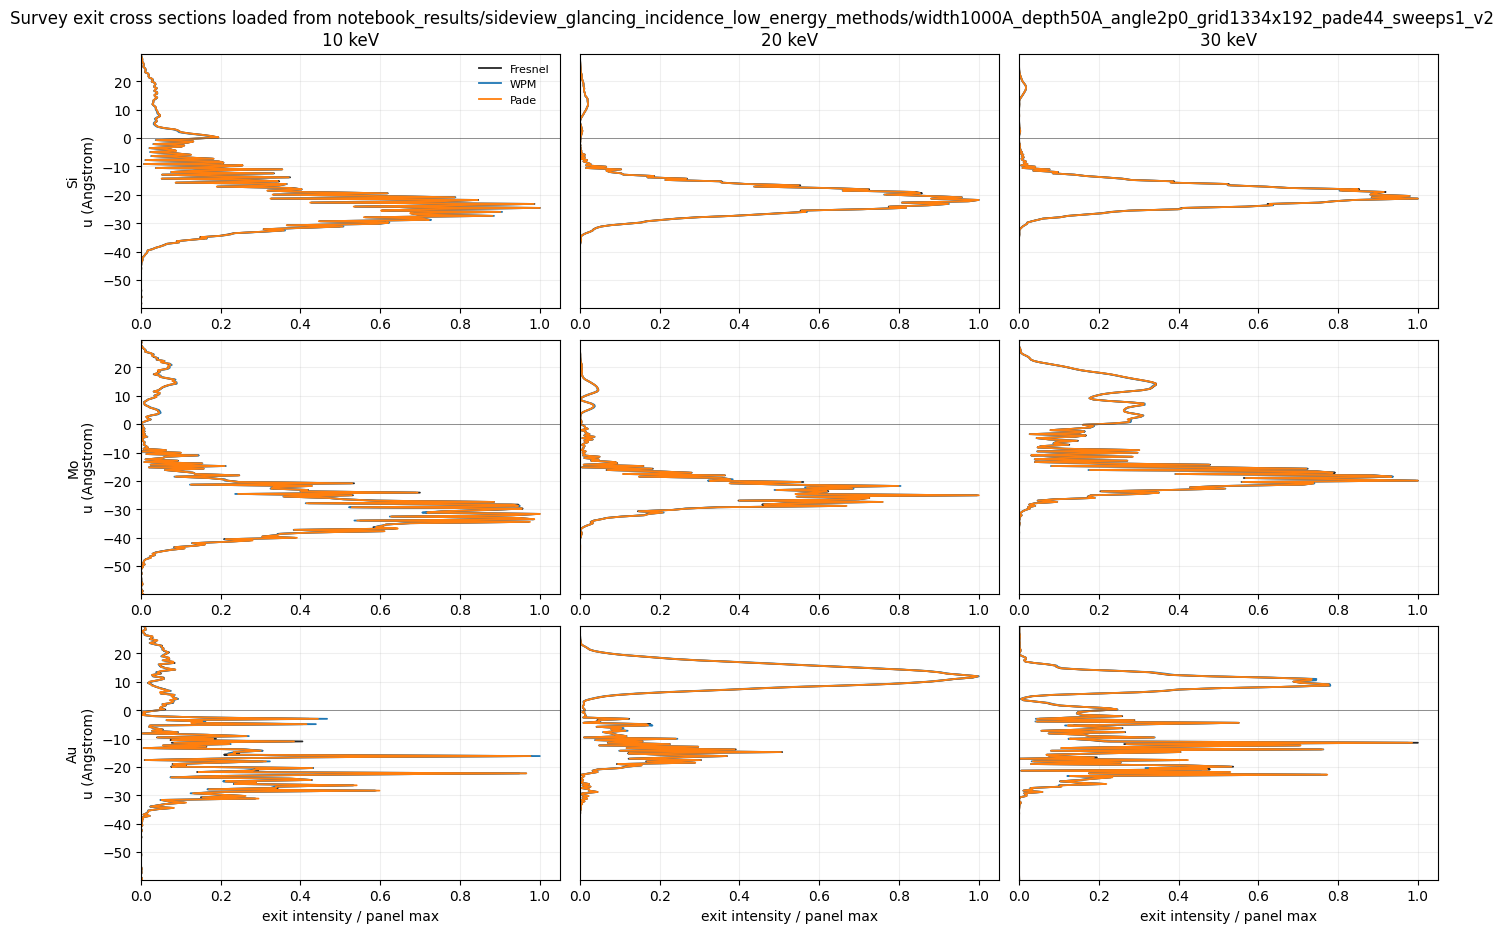

[{'material': 'Si',
  'energy_keV': 10.0,
  'grid_shape': [1334, 192],
  'sampling_A': [0.46875, 0.7496251874062968],
  'tilt_nyquist_fraction': 0.268079441784823,
  'lattice_nyquist_fraction': 0.27605420269058983,
  'cached_unique_slices': 16,
  'cache_file': 'notebook_results/sideview_glancing_incidence_low_energy_methods/width1000A_depth50A_angle2p0_grid1334x192_pade44_sweeps1_v2/Si_10keV_cross_sections.npz',
  'loaded_from_cache': True,
  'runtime_s': 123.94694490078837,
  'wpm_exit_intensity_rmse_vs_fresnel': 0.009787136557899171,
  'pade_exit_intensity_rmse_vs_fresnel': 0.005311632368079562,
  'pade_exit_intensity_rmse_vs_wpm': 0.007268165507724763,
  'wpm_farfield_rmse_vs_fresnel': 0.027522986298572544,
  'pade_farfield_rmse_vs_fresnel': 0.008685321610848895,
  'pade_farfield_rmse_vs_wpm': 0.02147341966098571,
  'wpm_reflected_power': 6.2426738983582e-08,
  'pade_reflected_power': 6.218487998677714e-08,
  'wpm_residual_last': 0.08918223405737419,
  'pade_residual_last': 0.088843

In [3]:
methods = ["Fresnel", "WPM", "Pade"]
method_colors = {"Fresnel": "0.15", "WPM": "tab:blue", "Pade": "tab:orange"}
sideview_norm = max(
    float(jnp.max(jnp.abs(method_results[method]["wavefronts"]) ** 2))
    for method in methods
) + 1e-30
exit_norm = float(jnp.max(jnp.abs(method_results["Fresnel"]["wave"]) ** 2)) + 1e-30
farfield_norm = float(jnp.max(method_farfields["Fresnel"][positive_angle_mask])) + 1e-30
extent = [0.0, slab_width_A, float(u[0]), float(u[-1])]
u_limits = (float(u[0]), float(u[-1]))
positive_angle_limit = float(np.max(detector_angle_mrad[positive_angle_mask]))
positive_farfield_ylim = 1.05 * max(
    float(jnp.max(method_farfields[method][positive_angle_mask] / farfield_norm))
    for method in methods
)

fig, axes = plt.subplots(
    len(methods),
    3,
    figsize=(16.5, 10.4),
    constrained_layout=True,
    gridspec_kw={"width_ratios": [5.0, 1.25, 2.4]},
)

for row, method in enumerate(methods):
    result = method_results[method]
    wavefront_display = np.sqrt(np.asarray(jnp.abs(result["wavefronts"]) ** 2) / sideview_norm)
    ax_side, ax_out, ax_far = axes[row]

    ax_side.imshow(
        wavefront_display.T,
        extent=extent,
        origin="lower",
        aspect="auto",
        cmap="magma",
        vmin=0.0,
        vmax=1.0,
    )
    ax_side.scatter(
        atom_marker_s,
        atom_marker_u,
        s=1.0,
        c="cyan",
        alpha=0.45,
        linewidths=0,
        rasterized=True,
    )
    ax_side.axhline(0.0, color="cyan", lw=0.7, alpha=0.75)
    ax_side.set_ylim(u_limits)
    ax_side.set_title(f"{method} sideview intensity")
    ax_side.set_xlabel("path coordinate (Angstrom)")
    ax_side.set_ylabel("u (Angstrom)")
    ax_out.sharey(ax_side)

    method_exit = jnp.abs(result["wave"]) ** 2 / exit_norm
    fresnel_exit = jnp.abs(method_results["Fresnel"]["wave"]) ** 2 / exit_norm
    if method != "Fresnel":
        ax_out.plot(np.asarray(fresnel_exit), np.asarray(u), color="0.65", lw=1.1, label="Fresnel")
    ax_out.plot(np.asarray(method_exit), np.asarray(u), color=method_colors[method], lw=1.4, label=method)
    ax_out.set_xlabel("intensity / Fresnel max")
    ax_out.set_xlim(0.0, max(1.05, 1.05 * float(jnp.max(method_exit))))
    ax_out.set_ylim(u_limits)
    ax_out.tick_params(axis="y", left=False, labelleft=False)
    ax_out.grid(alpha=0.2)
    ax_out.legend(fontsize=8, frameon=False)

    method_farfield = method_farfields[method] / farfield_norm
    fresnel_farfield = method_farfields["Fresnel"] / farfield_norm
    if method != "Fresnel":
        ax_far.plot(
            detector_angle_mrad[positive_angle_mask],
            np.asarray(fresnel_farfield)[positive_angle_mask],
            color="0.65",
            lw=1.1,
            label="Fresnel",
        )
    ax_far.plot(
        detector_angle_mrad[positive_angle_mask],
        np.asarray(method_farfield)[positive_angle_mask],
        color=method_colors[method],
        lw=1.4,
        label=method,
    )
    ax_far.axvline(bounced_angle_mrad, color="tab:red", lw=0.9, ls="--", label="specular")
    ax_far.set_xlabel("positive detector angle (mrad)")
    ax_far.set_ylabel("intensity / Fresnel max")
    ax_far.set_xlim(0.0, positive_angle_limit)
    ax_far.set_ylim(0.0, positive_farfield_ylim)
    ax_far.set_title(f"positive-angle far field, R={comparison_summary[method]['reflected_power']:.2e}")
    ax_far.grid(alpha=0.2)
    ax_far.legend(fontsize=8, frameon=False)

fig.suptitle(
    f"{energy / 1e3:.0f} keV, {glancing_angle_degrees:.1f} deg incidence, "
    f"{slab_width_nm:.0f} nm x {slab_depth_nm:.0f} nm Si slab",
    y=1.01,
)
plt.show()

comparison_summary

if run_material_energy_survey and survey_results:
    survey_materials = list(survey_material_specs)
    survey_energy_labels = [f"{energy / 1e3:.0f}" for energy in survey_energies_eV]

    def survey_metric_grid(metric_name):
        grid = np.full((len(survey_materials), len(survey_energies_eV)), np.nan)
        for row in survey_results:
            i = survey_materials.index(row["material"])
            j = survey_energy_labels.index(f"{row['energy_keV']:.0f}")
            grid[i, j] = row[metric_name]
        return grid

    heatmaps = [
        ("WPM vs Fresnel\npositive far field RMSE", "wpm_farfield_rmse_vs_fresnel"),
        ("Pade vs Fresnel\npositive far field RMSE", "pade_farfield_rmse_vs_fresnel"),
        ("Pade vs WPM\npositive far field RMSE", "pade_farfield_rmse_vs_wpm"),
        ("WPM reflected power", "wpm_reflected_power"),
        ("Pade reflected power", "pade_reflected_power"),
        ("runtime per 3-method case (s)", "runtime_s"),
    ]
    fig_survey, axes_survey = plt.subplots(2, 3, figsize=(13.8, 7.4), constrained_layout=True)
    for ax, (title, metric_name) in zip(axes_survey.ravel(), heatmaps):
        values = survey_metric_grid(metric_name)
        image = ax.imshow(values, origin="upper", aspect="auto", cmap="viridis")
        ax.set_xticks(np.arange(len(survey_energy_labels)))
        ax.set_xticklabels(survey_energy_labels)
        ax.set_yticks(np.arange(len(survey_materials)))
        ax.set_yticklabels(survey_materials)
        ax.set_xlabel("beam energy (keV)")
        ax.set_title(title)
        for i in range(values.shape[0]):
            for j in range(values.shape[1]):
                ax.text(j, i, f"{values[i, j]:.2e}", ha="center", va="center", color="white", fontsize=8)
        fig_survey.colorbar(image, ax=ax, shrink=0.82)
    fig_survey.suptitle(
        f"Si/Mo/Au survey, {slab_width_nm:.0f} nm x {slab_depth_A:.0f} A slab, "
        f"grid={survey_n_steps} x {survey_n_u}, worst Nyquist fraction={survey_nyquist_fraction_max:.2f} <= {nyquist_safety_fraction:.2f}, "
        f"Pade {survey_pade_order}, sweeps={survey_backscatter_sweeps}",
        y=1.02,
    )
    plt.show()

    fig_cross, axes_cross = plt.subplots(
        len(survey_materials),
        len(survey_energies_eV),
        figsize=(13.8, 9.0),
        sharey=True,
        constrained_layout=True,
    )
    method_exit_keys = {"Fresnel": "fresnel_exit", "WPM": "wpm_exit", "Pade": "pade_exit"}
    for i, material_label in enumerate(survey_materials):
        for j, survey_energy in enumerate(survey_energies_eV):
            ax = axes_cross[i, j]
            row = next(
                row
                for row in survey_results
                if row["material"] == material_label and np.isclose(row["energy_keV"], survey_energy / 1e3)
            )
            cache_file = row.get("cache_file", str(survey_case_cache_path(material_label, survey_energy)))
            cross_section = load_survey_case_cross_sections(cache_file)
            u_cross = cross_section["u_A"]
            panel_norm = max(
                float(np.max(np.abs(cross_section[key]) ** 2))
                for key in method_exit_keys.values()
            ) + 1e-30
            for method in methods:
                intensity = np.abs(cross_section[method_exit_keys[method]]) ** 2 / panel_norm
                ax.plot(intensity, u_cross, color=method_colors[method], lw=1.3, label=method)
            ax.axhline(0.0, color="0.3", lw=0.7, alpha=0.6)
            ax.set_ylim(u_limits)
            ax.set_xlim(left=0.0)
            ax.grid(alpha=0.2)
            if i == 0:
                ax.set_title(f"{survey_energy / 1e3:.0f} keV")
            if j == 0:
                ax.set_ylabel(f"{material_label}\nu (Angstrom)")
            else:
                ax.tick_params(axis="y", left=False, labelleft=False)
            if i == len(survey_materials) - 1:
                ax.set_xlabel("exit intensity / panel max")
            if i == 0 and j == 0:
                ax.legend(fontsize=8, frameon=False)
    fig_cross.suptitle(
        f"Survey exit cross sections loaded from {survey_case_cache_dir}",
        y=1.02,
    )
    cross_section_figure_path = survey_case_cache_dir / "survey_exit_cross_sections.png"
    fig_cross.savefig(cross_section_figure_path, dpi=180)
    plt.show()

survey_results


## Sampling bandwidth check

The wide-angle correction is controlled by the dimensionless transverse frequency `q = lambda f_x = sin(theta)`, not by `dx` alone. A grid with pixel size `dx` can only represent `|q| <= lambda / (2 dx)`. If all represented and excited `q` values are small, Fresnel, WPM, and Pade should be very close even when WPM/Pade are implemented correctly. Wavelength-scale pixels are therefore needed only when the physics of interest contains large-angle components.

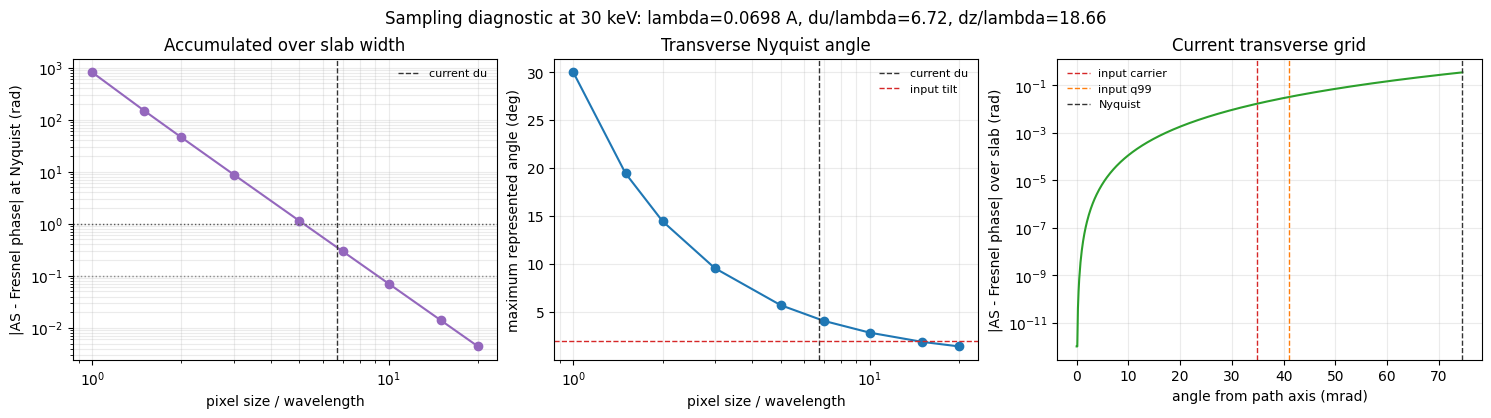

{'interpretation': 'Wide-angle differences need resolved spectral weight at q=lambda*f_x that is not small. Pixels of order lambda are necessary for tens-of-degrees content, but not for a few-degree glancing carrier.',
 'energy_keV': 30.0,
 'wavelength_A': 0.06979081544914424,
 'current_du_A': 0.46875,
 'current_dz_A': 1.3020833333333333,
 'current_du_over_lambda': 6.716499828570891,
 'current_dz_over_lambda': 18.656943968252474,
 'current_q_nyquist': 0.07444353647908719,
 'current_theta_nyquist_deg': 4.269249911699495,
 'incident_q': 0.03489949670250097,
 'incident_theta_deg': 2.0,
 'incident_abs_phase_error_rad_over_slab': 0.016704476312695244,
 'input_spectrum_q_quantiles': {'q50': 0.03451173993520521,
  'q90': 0.0378748547984346,
  'q99': 0.041099035764496056},
 'sampling_rows': [{'dx_over_lambda': 1.0,
   'theta_nyquist_deg': 30.000000000000004,
   'abs_phase_error_at_nyquist_rad_over_slab': 807.9723774050896},
  {'dx_over_lambda': 1.5,
   'theta_nyquist_deg': 19.47122063449069,
 

In [4]:
# Diagnostic for when the sampled problem has enough angular bandwidth for WPM/Pade
# to visibly separate from the Fresnel approximation.
def exact_minus_fresnel_phase_error_rad(q, distance_A, wavelength_A):
    q = np.asarray(q, dtype=float)
    q = np.clip(np.abs(q), 0.0, 1.0)
    exact_longitudinal = np.sqrt(np.maximum(0.0, 1.0 - q**2))
    fresnel_longitudinal = 1.0 - 0.5 * q**2
    return 2.0 * np.pi * distance_A / wavelength_A * (exact_longitudinal - fresnel_longitudinal)


def weighted_quantile(values, weights, quantiles):
    values = np.asarray(values, dtype=float).ravel()
    weights = np.asarray(weights, dtype=float).ravel()
    quantiles = np.asarray(quantiles, dtype=float)
    finite = np.isfinite(values) & np.isfinite(weights) & (weights > 0.0)
    if not np.any(finite):
        return np.full_like(quantiles, np.nan, dtype=float)
    values = values[finite]
    weights = weights[finite]
    order = np.argsort(values)
    values = values[order]
    cumulative = np.cumsum(weights[order])
    cumulative /= cumulative[-1]
    return np.interp(quantiles, cumulative, values)


dx_over_lambda_grid = np.array([1.0, 1.5, 2.0, 3.0, 5.0, 7.0, 10.0, 15.0, 20.0])
q_nyquist_grid = 0.5 / dx_over_lambda_grid
sampling_rows = []
for ratio, q_nyquist in zip(dx_over_lambda_grid, q_nyquist_grid):
    sampling_rows.append(
        {
            "dx_over_lambda": float(ratio),
            "theta_nyquist_deg": float(np.rad2deg(np.arcsin(np.clip(q_nyquist, 0.0, 1.0)))),
            "abs_phase_error_at_nyquist_rad_over_slab": float(
                abs(exact_minus_fresnel_phase_error_rad(q_nyquist, slab_width_A, wavelength_A))
            ),
        }
    )

target_angles_deg = np.array([2.0, 5.0, 10.0, 20.0, 30.0])
angle_sampling_requirements = [
    {
        "theta_deg": float(theta),
        "max_dx_over_lambda_for_nyquist": float(1.0 / (2.0 * np.sin(np.deg2rad(theta)))),
        "max_dx_A_at_current_energy": float(wavelength_A / (2.0 * np.sin(np.deg2rad(theta)))),
    }
    for theta in target_angles_deg
]

frequency_shifted = np.fft.fftshift(np.fft.fftfreq(n_u, d=du))
q_shifted = wavelength_A * frequency_shifted
current_q_nyquist = float(np.max(np.abs(q_shifted)))
current_theta_nyquist_deg = float(np.rad2deg(np.arcsin(np.clip(current_q_nyquist, 0.0, 1.0))))
incident_q = float(abs(np.sin(float(input_beam_tilt))))
incident_theta_deg = float(np.rad2deg(np.arcsin(np.clip(incident_q, 0.0, 1.0))))

input_spectrum_power = np.abs(np.fft.fftshift(np.fft.fft(np.asarray(input_wave)))) ** 2
input_q50, input_q90, input_q99 = weighted_quantile(
    np.abs(q_shifted),
    input_spectrum_power,
    [0.50, 0.90, 0.99],
)

exit_spectrum_rows = []
for method in methods:
    q50, q90, q99 = weighted_quantile(
        np.abs(q_shifted),
        np.asarray(method_farfields[method]),
        [0.50, 0.90, 0.99],
    )
    exit_spectrum_rows.append(
        {
            "method": method,
            "q50": float(q50),
            "q90": float(q90),
            "q99": float(q99),
            "theta99_mrad": float(1e3 * np.arcsin(np.clip(q99, 0.0, 1.0))),
            "abs_phase_error_q99_rad_over_slab": float(
                abs(exact_minus_fresnel_phase_error_rad(q99, slab_width_A, wavelength_A))
            ),
        }
    )

fig_sampling, axes_sampling = plt.subplots(1, 3, figsize=(14.8, 3.8), constrained_layout=True)

phase_error_grid = np.array(
    [abs(exact_minus_fresnel_phase_error_rad(q, slab_width_A, wavelength_A)) for q in q_nyquist_grid]
)
axes_sampling[0].loglog(dx_over_lambda_grid, phase_error_grid, "o-", color="tab:purple")
axes_sampling[0].axvline(du / wavelength_A, color="0.2", ls="--", lw=1.0, label="current du")
axes_sampling[0].axhline(0.1, color="0.55", ls=":", lw=1.0)
axes_sampling[0].axhline(1.0, color="0.35", ls=":", lw=1.0)
axes_sampling[0].set_xlabel("pixel size / wavelength")
axes_sampling[0].set_ylabel("|AS - Fresnel phase| at Nyquist (rad)")
axes_sampling[0].set_title("Accumulated over slab width")
axes_sampling[0].grid(alpha=0.25, which="both")
axes_sampling[0].legend(frameon=False, fontsize=8)

theta_nyquist_grid = np.rad2deg(np.arcsin(np.clip(q_nyquist_grid, 0.0, 1.0)))
axes_sampling[1].semilogx(dx_over_lambda_grid, theta_nyquist_grid, "o-", color="tab:blue")
axes_sampling[1].axvline(du / wavelength_A, color="0.2", ls="--", lw=1.0, label="current du")
axes_sampling[1].axhline(incident_theta_deg, color="tab:red", ls="--", lw=1.0, label="input tilt")
axes_sampling[1].set_xlabel("pixel size / wavelength")
axes_sampling[1].set_ylabel("maximum represented angle (deg)")
axes_sampling[1].set_title("Transverse Nyquist angle")
axes_sampling[1].grid(alpha=0.25, which="both")
axes_sampling[1].legend(frameon=False, fontsize=8)

q_eval = np.linspace(0.0, min(current_q_nyquist, 0.999), 600)
theta_eval_mrad = 1e3 * np.arcsin(np.clip(q_eval, 0.0, 1.0))
phase_eval = np.abs(exact_minus_fresnel_phase_error_rad(q_eval, slab_width_A, wavelength_A))
axes_sampling[2].semilogy(theta_eval_mrad, np.maximum(phase_eval, 1e-12), color="tab:green")
for q_marker, label, color in [
    (incident_q, "input carrier", "tab:red"),
    (input_q99, "input q99", "tab:orange"),
    (current_q_nyquist, "Nyquist", "0.2"),
]:
    axes_sampling[2].axvline(
        1e3 * np.arcsin(np.clip(q_marker, 0.0, 1.0)),
        color=color,
        ls="--",
        lw=1.0,
        label=label,
    )
axes_sampling[2].set_xlabel("angle from path axis (mrad)")
axes_sampling[2].set_ylabel("|AS - Fresnel phase| over slab (rad)")
axes_sampling[2].set_title("Current transverse grid")
axes_sampling[2].grid(alpha=0.25, which="both")
axes_sampling[2].legend(frameon=False, fontsize=8)

fig_sampling.suptitle(
    f"Sampling diagnostic at {energy / 1e3:.0f} keV: lambda={wavelength_A:.4f} A, "
    f"du/lambda={du / wavelength_A:.2f}, dz/lambda={path_step / wavelength_A:.2f}",
    y=1.06,
)
plt.show()

sampling_diagnostic_summary = {
    "interpretation": (
        "Wide-angle differences need resolved spectral weight at q=lambda*f_x that is not small. "
        "Pixels of order lambda are necessary for tens-of-degrees content, but not for a few-degree glancing carrier."
    ),
    "energy_keV": float(energy / 1e3),
    "wavelength_A": float(wavelength_A),
    "current_du_A": float(du),
    "current_dz_A": float(path_step),
    "current_du_over_lambda": float(du / wavelength_A),
    "current_dz_over_lambda": float(path_step / wavelength_A),
    "current_q_nyquist": current_q_nyquist,
    "current_theta_nyquist_deg": current_theta_nyquist_deg,
    "incident_q": incident_q,
    "incident_theta_deg": incident_theta_deg,
    "incident_abs_phase_error_rad_over_slab": float(
        abs(exact_minus_fresnel_phase_error_rad(incident_q, slab_width_A, wavelength_A))
    ),
    "input_spectrum_q_quantiles": {
        "q50": float(input_q50),
        "q90": float(input_q90),
        "q99": float(input_q99),
    },
    "sampling_rows": sampling_rows,
    "angle_sampling_requirements": angle_sampling_requirements,
    "exit_spectrum_rows": exit_spectrum_rows,
}
sampling_diagnostic_summary
